<a href="https://colab.research.google.com/github/harshana-cs/Ai-Ml/blob/main/Worksheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task - 1: Implementation of MCP Neurons:

1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two
input

In [54]:
def MCP_Neurons_AND(X1, X2, T):
  assert len(X1) == len(X2)
  state_neuron=[]
  for i in range(len(X1)):
    sum = X1[i] + X2[i]
    if sum >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

In [55]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [56]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    state_neuron=[]
    for i in range(len(X1)):
      sum = X1[i] + X2[i]
      if sum >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron


In [57]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.                              
Ans: Limited to linearly separable Boolean functions                            Lacks measure of importance (weights)



     


 Question 2: Think if you can develop a logic to solve for XOR function using

## **4 The Perceptron.**

# 4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [58]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AIML/Data/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


1. Question - 1: What does the shape of X represent?
Ans: Shape X represents rows of dataset
2. Question - 2: What does the shape of y represent?
Ans: Shape y represents the labels of the dataset.

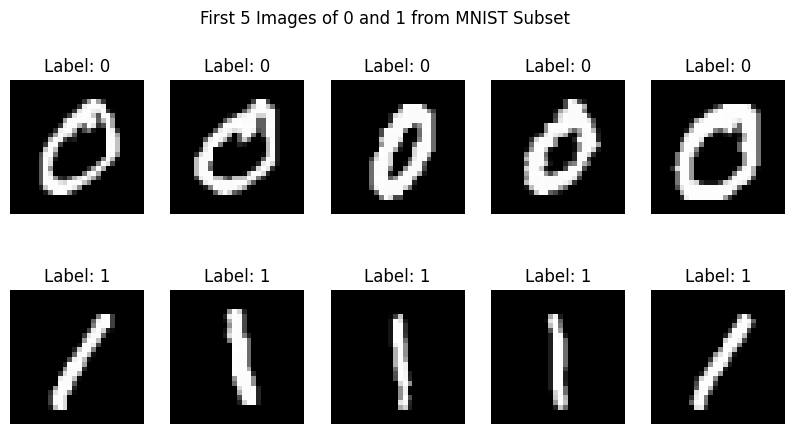

In [59]:
import matplotlib.pyplot as plt
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
# Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
# Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

In [60]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question - 3: What does the weights array represent in this context?
2. Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

In [61]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

In [62]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    for epoch in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0
            if y_pred != y[i]:
                error = y[i] - y_pred
                weights += learning_rate * error * X[i]
                bias += learning_rate * error
    accuracy=np.mean(decision_function(X, weights, bias) == y)
    print("Epochs", epochs);

    return weights, bias, accuracy

Answer the Following Question:
1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?
2. Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?
3. Question - 7:Why is the final accuracy important, and what do you expect it to be?

In [63]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epochs 100
The Final Accuracy is:  1.0


In [64]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question - 8:What does misclassified idx store, and how is it used in this code?
2. Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AIML/Data/mnist_3_and_5.csv")

# Extract features and labels
X1 = df_3_5.drop(columns=["label"]).values
y1 = df_3_5["label"].values

print("Shape:", X1.shape, y1.shape)

Shape: (2741, 784) (2741,)


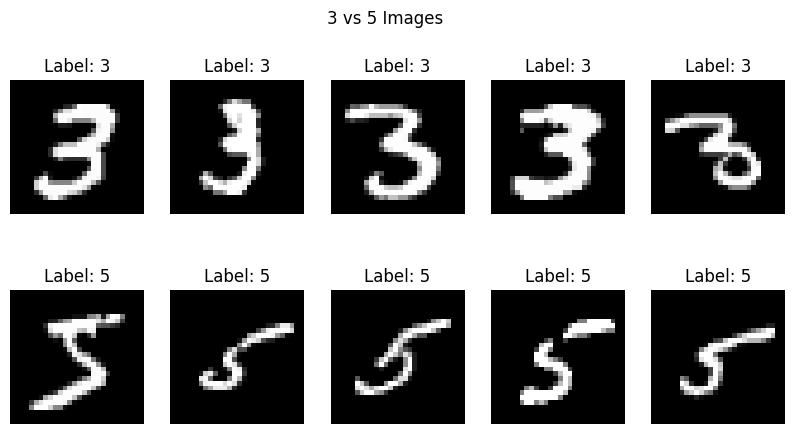

In [66]:
import matplotlib.pyplot as plt
# Separate images for label 0 and label 1
images_3 = X1[y1 == 3]
images_5 = X1[y1 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("3 vs 5 Images")
plt.show()

In [67]:
X1 = X1 / 255.0
# Convert labels
y_original = y1.copy()
y1 = np.where(y1 == 3, 0, 1)

# Shuffle data
indices = np.arange(len(X1))
np.random.shuffle(indices)

X1 = X1[indices]
y1 = y1[indices]

In [68]:
# Initialize weights and bias
weights1 = np.zeros(X1.shape[1]) # 784 weights (one for each pixel)
bias1 = 0
learning_rate1 = 0.1
epochs1 = 100

In [69]:
import numpy as np

def decision_function(X1, weights1, bias1):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X1, weights1) + bias1
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

In [70]:
def train_perceptron(X1, y1, weights1, bias1, learning_rate1=0.1, epochs1=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    print(f"\nStarting Perceptron Training (Epochs: {epochs}, Learning Rate: {learning_rate})")

    for epoch in range(epochs1):
        num_errors = 0
        for i in range(len(X1)):
            z = np.dot(X1[i], weights1) + bias1
            y_pred1 = 1 if z >= 0 else 0
            if y_pred1 != y1[i]:
                num_errors += 1
                error = y1[i] - y_pred1
                weights1 += learning_rate1 * error * X1[i]
                bias1 += learning_rate1 * error

        # Print progress every 10 epochs or if there are errors
        if (epoch + 1) % 10 == 0 or num_errors > 0:
            current_accuracy = np.mean(decision_function(X1, weights1, bias1) == y1)
            print(f"Epoch {epoch+1}/{epochs1}, Errors: {num_errors}, Current Accuracy: {current_accuracy:.4f}")
            if num_errors == 0: # If no errors, perceptron has converged for this dataset
                print(f"Perceptron converged at Epoch {epoch+1}")
                break # Stop training if converged

    accuracy1=np.mean(decision_function(X1, weights1, bias1) == y1)
    print(f"\nFinal Training Accuracy: {accuracy:.4f}");

    return weights1, bias1, accuracy1

In [71]:
# After training the model with the perceptron_learning_algorithm
weights1, bias1, accuracy1 = train_perceptron(X1, y1, weights1, bias1)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy1)


Starting Perceptron Training (Epochs: 100, Learning Rate: 0.1)
Epoch 1/100, Errors: 266, Current Accuracy: 0.9197
Epoch 2/100, Errors: 194, Current Accuracy: 0.9559
Epoch 3/100, Errors: 182, Current Accuracy: 0.9376
Epoch 4/100, Errors: 153, Current Accuracy: 0.9033
Epoch 5/100, Errors: 145, Current Accuracy: 0.9588
Epoch 6/100, Errors: 141, Current Accuracy: 0.9420
Epoch 7/100, Errors: 139, Current Accuracy: 0.9595
Epoch 8/100, Errors: 122, Current Accuracy: 0.9475
Epoch 9/100, Errors: 136, Current Accuracy: 0.9613
Epoch 10/100, Errors: 109, Current Accuracy: 0.9325
Epoch 11/100, Errors: 114, Current Accuracy: 0.9497
Epoch 12/100, Errors: 126, Current Accuracy: 0.9577
Epoch 13/100, Errors: 119, Current Accuracy: 0.9701
Epoch 14/100, Errors: 118, Current Accuracy: 0.9591
Epoch 15/100, Errors: 115, Current Accuracy: 0.8898
Epoch 16/100, Errors: 97, Current Accuracy: 0.9493
Epoch 17/100, Errors: 106, Current Accuracy: 0.9788
Epoch 18/100, Errors: 103, Current Accuracy: 0.9540
Epoch 19/1

Total Misclassified: 56


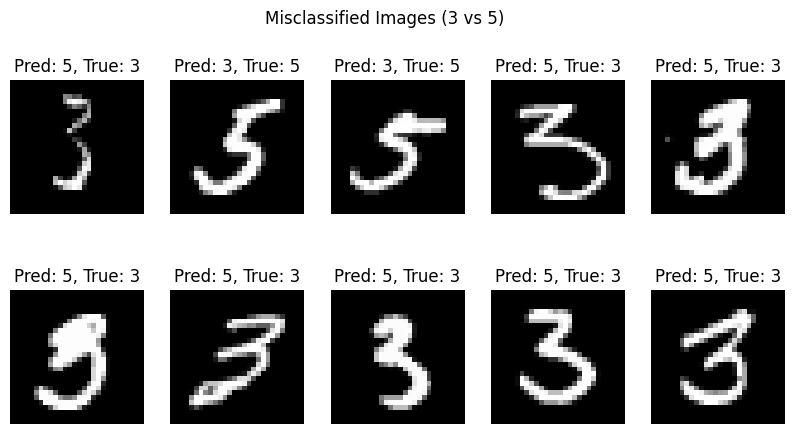

In [74]:
# Predictions
y_pred1 = decision_function(X1, weights1, bias1)

# Find misclassified indices
misclassified_idx = np.where(y_pred1 != y1)[0]

print("Total Misclassified:", len(misclassified_idx))

# Show images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X1[idx].reshape(28, 28), cmap="gray")

        # IMPORTANT: Show original labels (3 and 5)
        true_label = 3 if y1[idx] == 0 else 5
        pred_label = 3 if y_pred1[idx] == 0 else 5

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")